# Housing Price Prediction using a Neural Network

## Objective
In this exercise, you will:
1. Create a synthetic dataset for housing prices based on a linear equation.
2. Build and train a simple neural network with one neuron to predict housing prices.

---

## Step 1: Import Libraries
Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

---

## Step 2: Create a Synthetic Dataset
We will create a dataset for housing prices that follows the equation

$\text{price}$ = $\text{number of bedrooms}$ $\times  x$ + $\text{base price}$


In [2]:
# Number of samples
n_samples = 1000

# Generate random number of bedrooms between 1 and 5
bedrooms = np.random.randint(1, 6, n_samples)

# Constants for the equation
x = 0.5  # The price added per bedroom in onehundred thousands
base_price = 1  # Base price of a house in onehundred thousands

# Generate housing prices based on the equation
prices = bedrooms * x + base_price

# Create a DataFrame
df = pd.DataFrame({'bedrooms': bedrooms, 'price': prices})

# Show the first few rows
df.head()

,bedrooms,price
0,2,2.0
1,5,3.5
2,4,3.0
3,2,2.0
4,2,2.0


---

## Step 3: Visualize the Data
Plot the data to visualize the relationship between the number of bedrooms and the price.


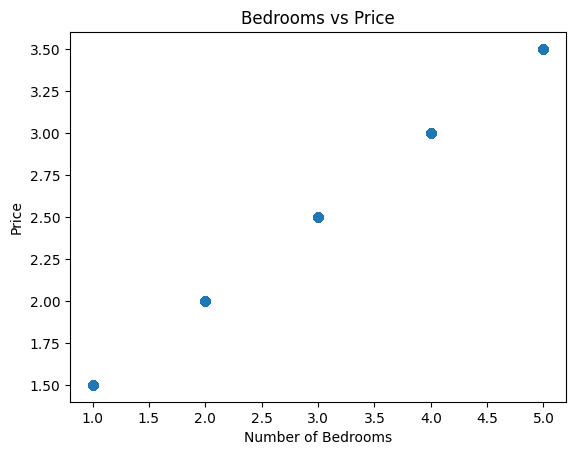

In [3]:
plt.scatter(df['bedrooms'], df['price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Bedrooms vs Price')
plt.show()


---

## Step 4: Preprocess the Data
Split the data into features (`X`) and labels (`y`), and then into training and testing sets.


In [4]:
# Features and Labels
X = df[['bedrooms']]
y = df['price']

# TODO Split the data
# YOUR CODE HERE
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 1)
X_test shape: (200, 1)
y_train shape: (800,)
y_test shape: (200,)


---

## Step 5: Build a Neural Network
Build a simple neural network with one neuron to predict the house prices.
Pick a loss function that suits this problem.


In [5]:
from tensorflow import keras
from keras import layers

# TODO Create the model
model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(1)
])

# TODO Compile the model
model.compile(
    optimizer='adam',
    loss='mse'
)

# TODO print a Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

---

## Step 6: Train the Model
Train the model using the training data.


In [ ]:
# TODO Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

---

## Step 7: Evaluate the Model
Evaluate the model using the test data and plot its prediction.


Test loss: 6.901297569274902
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


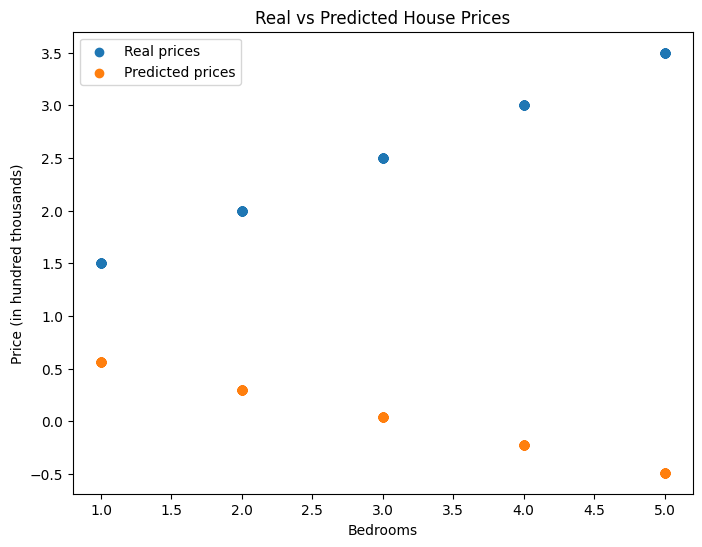

In [7]:
# TODO Evaluate the model using the model.evaluate() function
test_loss = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)

# TODO Make predictions
y_pred = model.predict(X_test)

# TODO Plot real vs predicted prices (hint: you can use the plotting code from above as a start)
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, label='Real prices')
plt.scatter(X_test, y_pred, label='Predicted prices')
plt.xlabel('Bedrooms')
plt.ylabel('Price (in hundred thousands)')
plt.title('Real vs Predicted House Prices')
plt.legend()
plt.show()

# Step 8: Optional
Go back to the start and experiment what happens if instead of representing a price of a house costing onehundred thousand by a 1 we use the raw number 100,000 instead.

Try to explain what happened and why.

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 65672171520.0000 - val_loss: 62547140608.0000
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65672130560.0000 - val_loss: 62547099648.0000
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65672093696.0000 - val_loss: 62547058688.0000
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65672052736.0000 - val_loss: 62547013632.0000
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65672007680.0000 - val_loss: 62546976768.0000
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65671966720.0000 - val_loss: 62546935808.0000
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65671913472.0000 - val_loss: 62546903040.0000
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 65671888896.0000 - val_loss: 62546862080.0000
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 65671835648.0000 - val_loss: 62546817024.0000
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6567

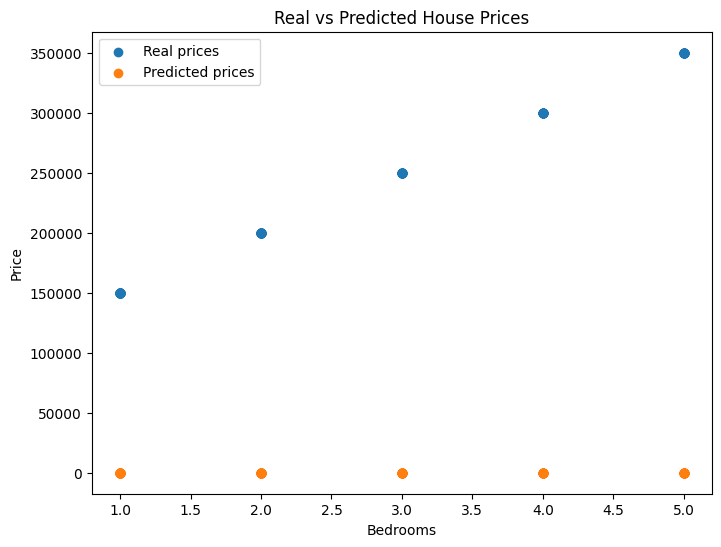

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Number of samples
n_samples = 1000

# Generate random number of bedrooms between 1 and 5
bedrooms = np.random.randint(1, 6, n_samples)

# Raw-price version
x = 50000      # price added per bedroom
base_price = 100000  # base house price

# Generate housing prices
prices = bedrooms * x + base_price

# Create DataFrame
df = pd.DataFrame({
    'bedrooms': bedrooms,
    'price': prices
})

# Features and labels
X = df[['bedrooms']]
y = df['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-neuron model
model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse'
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)

# Predict
y_pred = model.predict(X_test)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, label="Real prices")
plt.scatter(X_test, y_pred, label="Predicted prices")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Real vs Predicted House Prices")
plt.legend()
plt.show()